1) Importe o conjunto de dados con do no arquivo Base_App.csv para o ambiente 
de análise. 

In [1]:
import pandas as pd

# Lê o arquivo corretamente com separador ;
df = pd.read_csv('Base_App.csv', sep=';')

# Exibe as 5 primeiras linhas do DataFrame
df.head()


,App,Sexo,Estado_civil,renda,satisfacao,Gasto
0,1,1,1,"2066,13","86,93","43,06"
1,1,1,1,"1920,41","84,85","53,94"
2,1,1,2,"2632,14","82,33","43,30"
3,1,1,1,"2488,07","81,57","48,89"
4,1,1,1,"2094,67","80,80","52,98"


2) Faça o tratamento das variáveis qualitativas.

Colunas: ['App', 'Sexo', 'Estado_civil', 'renda', 'satisfacao', 'Gasto']

Descrição da coluna 'satisfacao':
count    250.000000
mean      69.719120
std        4.951877
min       56.600000
25%       66.467500
50%       69.590000
75%       72.982500
max       86.930000
Name: satisfacao, dtype: float64


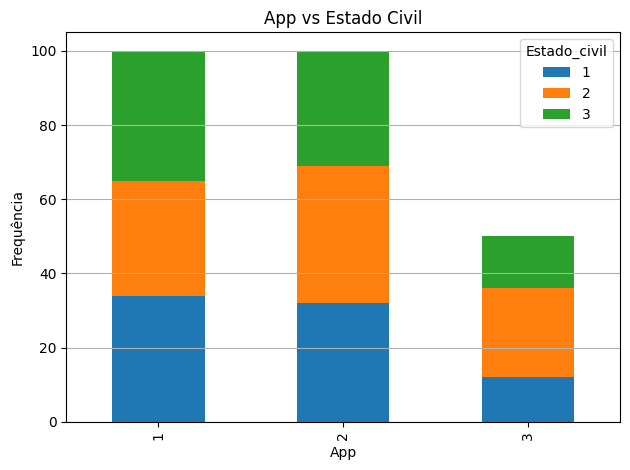

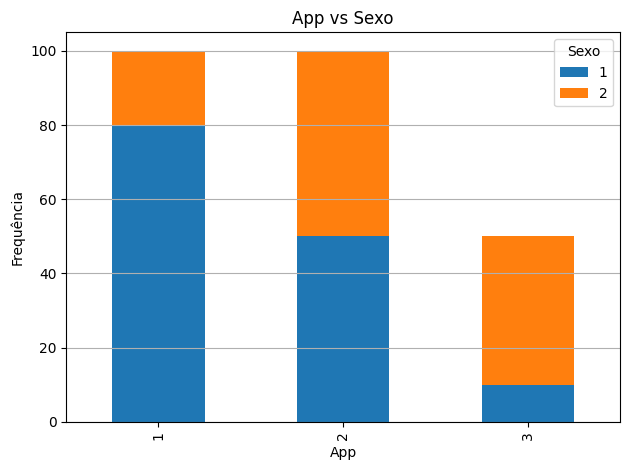

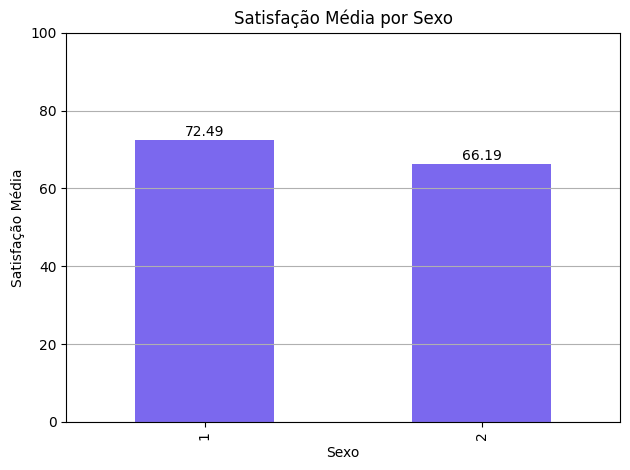

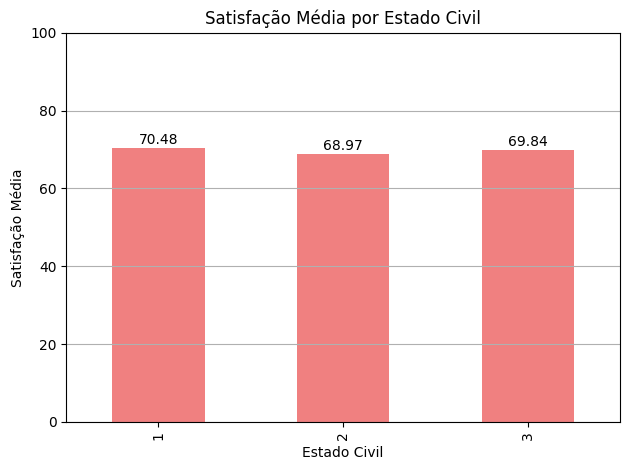

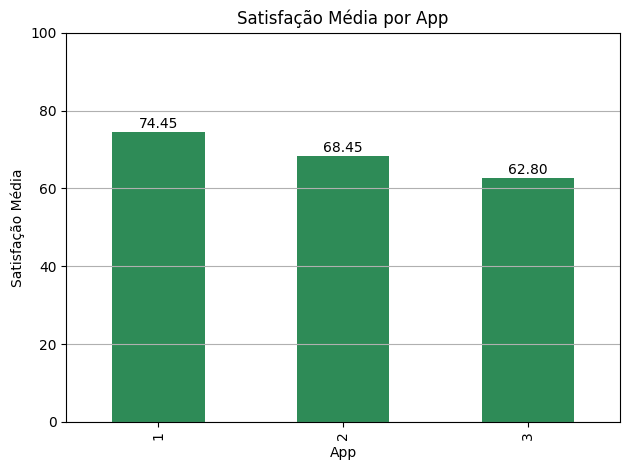

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Lê o arquivo CSV com separador ;
df = pd.read_csv('Base_App.csv', sep=';')

# Remove espaços em branco e caracteres ocultos dos nomes das colunas
df.columns = df.columns.str.strip().str.replace(r'[\r\n]+', '', regex=True)

# Corrige separador decimal na coluna de satisfação
df['satisfacao'] = df['satisfacao'].str.replace(',', '.')
df['satisfacao'] = pd.to_numeric(df['satisfacao'], errors='coerce')

# Converte Sexo para string
df['Sexo'] = df['Sexo'].astype(str)

# Verifica nomes das colunas
print("Colunas:", df.columns.tolist())
print("\nDescrição da coluna 'satisfacao':")
print(df['satisfacao'].describe())

# --- GRÁFICO 1: App vs Estado Civil ---
pd.crosstab(df['App'], df['Estado_civil']).plot(kind='bar', stacked=True)
plt.title('App vs Estado Civil')
plt.ylabel('Frequência')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- GRÁFICO 2: App vs Sexo ---
pd.crosstab(df['App'], df['Sexo']).plot(kind='bar', stacked=True)
plt.title('App vs Sexo')
plt.ylabel('Frequência')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- GRÁFICO 3: Satisfação média por Sexo ---
media_satisfacao_por_sexo = df.groupby('Sexo')['satisfacao'].mean()
media_satisfacao_por_sexo.plot(kind='bar', color='mediumslateblue')
plt.title('Satisfação Média por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Satisfação Média')
plt.ylim(0, 100)
for idx, valor in enumerate(media_satisfacao_por_sexo):
    plt.text(idx, valor + 1, f'{valor:.2f}', ha='center')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- GRÁFICO 4: Satisfação média por Estado Civil ---
media_satisfacao_estado = df.groupby('Estado_civil')['satisfacao'].mean()
media_satisfacao_estado.plot(kind='bar', color='lightcoral')
plt.title('Satisfação Média por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Satisfação Média')
plt.ylim(0, 100)
for idx, valor in enumerate(media_satisfacao_estado):
    plt.text(idx, valor + 1, f'{valor:.2f}', ha='center')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- GRÁFICO 5: Satisfação média por App ---
media_satisfacao_app = df.groupby('App')['satisfacao'].mean()
media_satisfacao_app.plot(kind='bar', color='seagreen')
plt.title('Satisfação Média por App')
plt.xlabel('App')
plt.ylabel('Satisfação Média')
plt.ylim(0, 100)
for idx, valor in enumerate(media_satisfacao_app):
    plt.text(idx, valor + 1, f'{valor:.2f}', ha='center')
plt.grid(axis='y')
plt.tight_layout()
plt.show()



3) Você diria que existe associação entre App e Sexo. Apresente a análise mais 
completa, contendo tabela de contingência, gráfico, medida de associação e o 
teste de hipóteses. 

Tabela de Contingência entre Sexo e Uso do App:
App    1   2   3
Sexo            
1     80  50  10
2     20  50  40


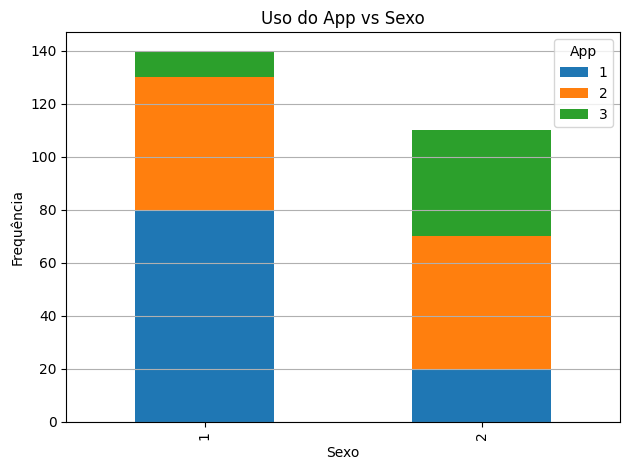

Qui-Quadrado: 51.13636363636364
Valor p: 7.868278510255523e-12
Grau de Liberdade: 2
Valores Esperados:
[[56. 56. 28.]
 [44. 44. 22.]]
Rejeitamos a hipótese nula: Existe associação entre o uso do App e o sexo.


In [3]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Criando a Tabela de Contingência entre Sexo e Uso do App
tabela_contingencia = pd.crosstab(df['Sexo'], df['App'])
print("Tabela de Contingência entre Sexo e Uso do App:")
print(tabela_contingencia)

# --- Gráfico de Barras Empilhadas ---
tabela_contingencia.plot(kind='bar', stacked=True)
plt.title('Uso do App vs Sexo')
plt.xlabel('Sexo')
plt.ylabel('Frequência')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- Teste de Qui-Quadrado ---
chi2, p, dof, expected = chi2_contingency(tabela_contingencia)
print(f"Qui-Quadrado: {chi2}")
print(f"Valor p: {p}")
print(f"Grau de Liberdade: {dof}")
print(f"Valores Esperados:\n{expected}")

# Se p < 0,05, existe associação significativa
if p < 0.05:
    print("Rejeitamos a hipótese nula: Existe associação entre o uso do App e o sexo.")
else:
    print("Não rejeitamos a hipótese nula: Não há associação significativa entre o uso do App e o sexo.")


4) Você diria que existe associação entre App e Estado_civil. Apresente a análise 
mais completa, contendo tabela de con ngência, gráfico, medida de associação 
e o teste de hipóteses. 

Tabela de Contingência entre Estado Civil e Uso do App:
App            1   2   3
Estado_civil            
1             34  32  12
2             31  37  24
3             35  31  14


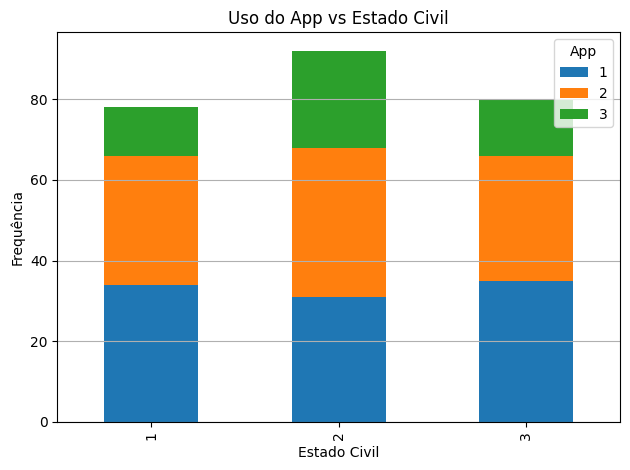

Qui-Quadrado: 4.284629319955407
Valor p: 0.3688537781092168
Grau de Liberdade: 4
Valores Esperados:
[[31.2 31.2 15.6]
 [36.8 36.8 18.4]
 [32.  32.  16. ]]
Não rejeitamos a hipótese nula: Não há associação significativa entre o uso do App e o estado civil.


In [4]:
import pandas as pd
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

# Criando a Tabela de Contingência entre Estado Civil e Uso do App
tabela_contingencia_estado = pd.crosstab(df['Estado_civil'], df['App'])
print("Tabela de Contingência entre Estado Civil e Uso do App:")
print(tabela_contingencia_estado)

# --- Gráfico de Barras Empilhadas ---
tabela_contingencia_estado.plot(kind='bar', stacked=True)
plt.title('Uso do App vs Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Frequência')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# --- Teste de Qui-Quadrado ---
chi2, p, dof, expected = chi2_contingency(tabela_contingencia_estado)
print(f"Qui-Quadrado: {chi2}")
print(f"Valor p: {p}")
print(f"Grau de Liberdade: {dof}")
print(f"Valores Esperados:\n{expected}")

# Se p < 0,05, existe associação significativa
if p < 0.05:
    print("Rejeitamos a hipótese nula: Existe associação entre o uso do App e o estado civil.")
else:
    print("Não rejeitamos a hipótese nula: Não há associação significativa entre o uso do App e o estado civil.")


5) Você diria que existe correlação entre renda e satisfacao? Apresente a análise 
mais completa, contendo gráfico, medida de correlação e o teste de hipóteses. 

App               int64
Sexo              int64
Estado_civil      int64
renda           float64
satisfacao      float64
Gasto           float64
dtype: object
   App  Sexo  Estado_civil    renda  satisfacao  Gasto
0    1     1             1  2066.13       86.93  43.06
1    1     1             1  1920.41       84.85  53.94
2    1     1             2  2632.14       82.33  43.30
3    1     1             1  2488.07       81.57  48.89
4    1     1             1  2094.67       80.80  52.98


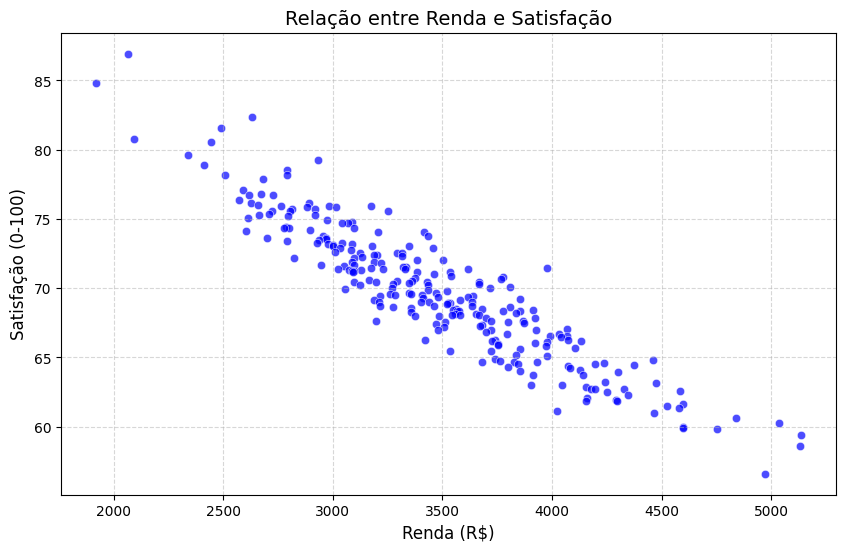

Coeficiente de Correlação de Pearson: -0.928


In [5]:
import pandas as pd

# Carregar os dados (garanta que o separador de colunas é ';')
df = pd.read_csv('Base_App.csv', sep=';')

# Converter colunas numéricas (substituir vírgula por ponto e converter para float)
cols_numericas = ['renda', 'satisfacao', 'Gasto']
for col in cols_numericas:
    df[col] = df[col].str.replace(',', '.').astype(float)

# Verificar os tipos de dados
print(df.dtypes)
# Verificar as primeiras linhas para garantir que os dados foram lidos corretamente
print(df.head())

plt.figure(figsize=(10, 6))
sns.scatterplot(x='renda', y='satisfacao', data=df, color='blue', alpha=0.7)
plt.title('Relação entre Renda e Satisfação', fontsize=14)
plt.xlabel('Renda (R$)', fontsize=12)
plt.ylabel('Satisfação (0-100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

corr_pearson = df['renda'].corr(df['satisfacao'], method='pearson')
print(f"Coeficiente de Correlação de Pearson: {corr_pearson:.3f}")

O valor -0.928 indica uma correlação negativa muito forte entre renda e satisfação.

Quanto maior a renda, menor a satisfação reportada

6) Você diria que existe correlação entre renda e Gasto? Apresente a análise mais 
completa, contendo gráfico, medida de correlação e o teste de hipóteses.

renda    float64
Gasto    float64
dtype: object


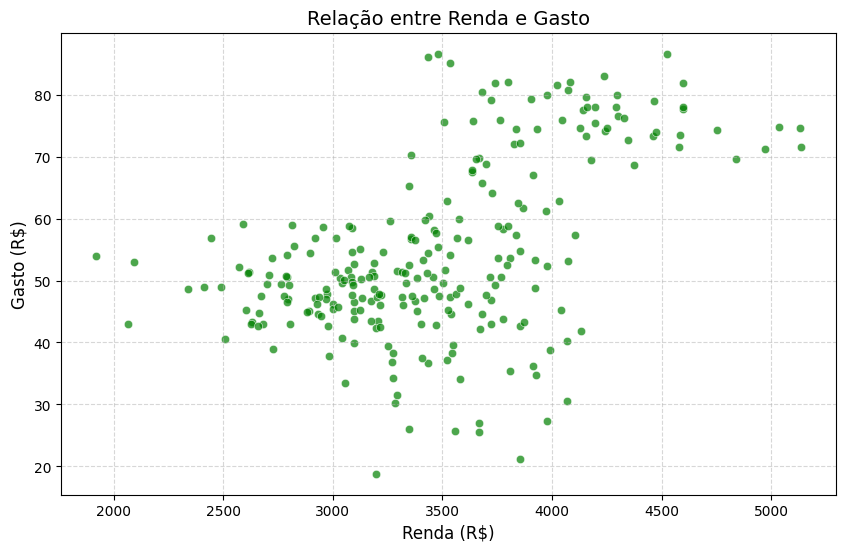

Coeficiente de Correlação de Pearson: 0.522


NameError: name 'stats' is not defined

In [6]:
# Carregar os dados (ajustando decimais se usar vírgula)
df = pd.read_csv('Base_App.csv', sep=';', decimal=',')  

# Verificar os tipos de dados
print(df[['renda', 'Gasto']].dtypes)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='renda', y='Gasto', data=df, color='green', alpha=0.7)
plt.title('Relação entre Renda e Gasto', fontsize=14)
plt.xlabel('Renda (R$)', fontsize=12)
plt.ylabel('Gasto (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
corr_pearson = df['renda'].corr(df['Gasto'], method='pearson')
print(f"Coeficiente de Correlação de Pearson: {corr_pearson:.3f}")

# Teste de Pearson
pearson_test = stats.pearsonr(df['renda'], df['Gasto'])
print(f"Coeficiente: {pearson_test[0]:.3f} | p-valor: {pearson_test[1]:.4f}")

0.9 a 1.0: Correlação positiva muito forte.

0.7 a 0.9: Forte.

0.5 a 0.7: Moderada.

< 0.5: Fraca ou insignificante.

O coeficiente igual a 0.52 explica uma correlação moderada, desta forma não há uma correlação decisiva que explique esta relação.

7) Você diria que existe associação entre App e Gasto? Apresente a análise mais 
completa, contendo medidas resumos e gráfico.

Categorias em 'App': [1 2 3]
     count     mean        std    min     50%    max
App                                                 
1    100.0  48.9880   4.722873  37.78  48.925  59.10
2    100.0  49.4045  13.642069  18.82  48.685  86.51
3     50.0  75.8826   4.922896  62.47  75.650  86.61


C:\Users\miris\AppData\Local\Temp\ipykernel_5368\2867818210.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='App', y='Gasto', data=df, palette='Set2')


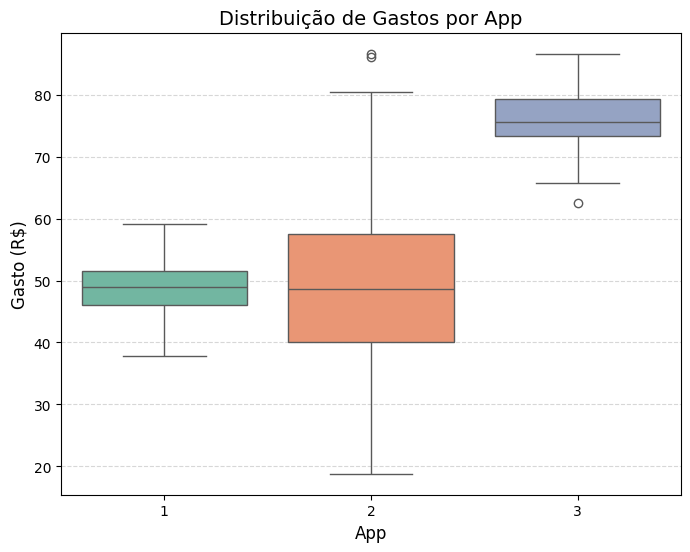

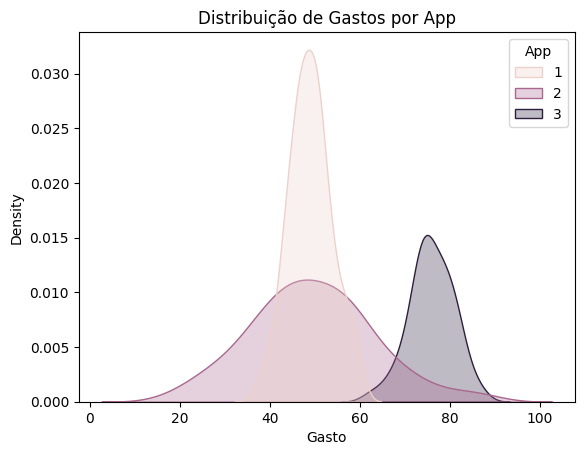

Coeficiente de Correlação de Pearson: 0.611
Coeficiente: 0.611 | p-valor: 0.0000


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Carregar os dados (ajustar decimal se necessário)
df = pd.read_csv('Base_App.csv', sep=';', decimal=',')

# Verificar categorias de 'App'
print("Categorias em 'App':", df['App'].unique())

# Estatísticas agrupadas
resumo = df.groupby('App')['Gasto'].describe(percentiles=[0.5])
print(resumo)

plt.figure(figsize=(8, 6))
sns.boxplot(x='App', y='Gasto', data=df, palette='Set2')
plt.title('Distribuição de Gastos por App', fontsize=14)
plt.xlabel('App', fontsize=12)
plt.ylabel('Gasto (R$)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

sns.kdeplot(data=df, x='Gasto', hue='App', fill=True, alpha=0.3)
plt.title('Distribuição de Gastos por App')
plt.show()

corr_pearson = df['App'].corr(df['Gasto'], method='pearson')
print(f"Coeficiente de Correlação de Pearson: {corr_pearson:.3f}")

# Teste de Pearson
pearson_test = stats.pearsonr(df['App'], df['Gasto'])
print(f"Coeficiente: {pearson_test[0]:.3f} | p-valor: {pearson_test[1]:.4f}")

Resposta: não diferença significativa entre o App 1 e 2, já o App 3 (Taxi Rio) apresenta uma relação de gasto maior.

8) Ajuste um modelo de regressão linear entre renda e sa sfação. Interprete os 
coeficientes esmados e o R2. Apresente a reta de regressão esmada 
graficamente. Avalie os gráficos de diagnós co.

In [ ]:
import statsmodels.api as sm
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar os dados (ajustar decimal se necessário)
df = pd.read_csv('Base_App.csv', sep=';', decimal=',')

# Definir variáveis
X = df['renda']  # Variável independente
y = df['satisfacao']  # Variável dependente

# Adicionar constante (intercepto)
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()
print(modelo.summary())



                            OLS Regression Results                            
Dep. Variable:             satisfacao   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     1544.
Date:                Wed, 07 May 2025   Prob (F-statistic):          1.66e-108
Time:                        17:25:15   Log-Likelihood:                -506.94
No. Observations:                 250   AIC:                             1018.
Df Residuals:                     248   BIC:                             1025.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         97.6376      0.720    135.621      0.0


Dados Experimentais vs. Ajustados:
       renda  satisfacao  ajustado
0    2066.13       86.93     81.03
1    1920.41       84.85     82.20
2    2632.14       82.33     76.48
3    2488.07       81.57     77.64
4    2094.67       80.80     80.80
..       ...         ...       ...
245  4598.41       59.90     60.68
246  4753.38       59.84     59.43
247  5133.44       59.39     56.37
248  5129.52       58.60     56.41
249  4972.53       56.60     57.67

[250 rows x 3 columns]

Coeficiente de Determinação (R²): 0.8616


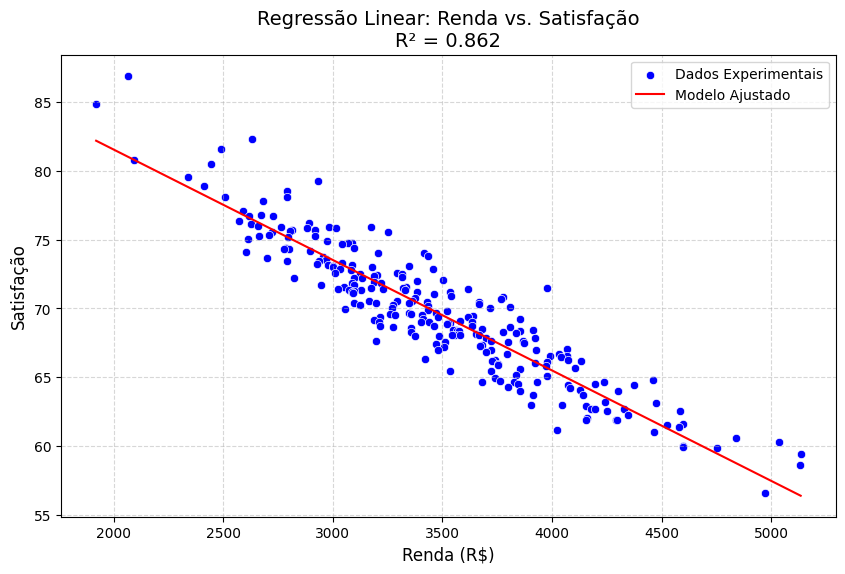

In [ ]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar os dados (ajuste o caminho e separadores conforme necessário)
df = pd.read_csv('Base_App.csv', sep=';', decimal=',')

# Ajustar o modelo de regressão
X = sm.add_constant(df['renda'])  # Adiciona intercepto
y = df['satisfacao']
modelo = sm.OLS(y, X).fit()

# Obter valores ajustados pelo modelo
df['ajustado'] = modelo.predict(X)

# Imprimir dados experimentais vs. ajustados
print("\nDados Experimentais vs. Ajustados:")
print(df[['renda', 'satisfacao', 'ajustado']].round(2))

# Imprimir R²
print(f"\nCoeficiente de Determinação (R²): {modelo.rsquared:.4f}")

# Plotar dados experimentais e reta ajustada
plt.figure(figsize=(10, 6))
sns.scatterplot(x='renda', y='satisfacao', data=df, label='Dados Experimentais', color='blue')
sns.lineplot(x='renda', y='ajustado', data=df, label='Modelo Ajustado', color='red')
plt.title(f'Regressão Linear: Renda vs. Satisfação\nR² = {modelo.rsquared:.3f}', fontsize=14)
plt.xlabel('Renda (R$)', fontsize=12)
plt.ylabel('Satisfação', fontsize=12)
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.show()

Resposta: R2 igual a 86.2% explica uma correlação entre os dados experimentais e obtidos pelo modelo teórico. Para melhorar esta correlação pode-se aumentar o grau do polinômio (usou-se uma reta, podemos usar um polinômio de grau dois).